# NICAR 2026 geopandas demo

This notebook demonstrates a geospatial analysis of San Francisco trees, neighborhoods, and schools. 

**Data in the `data/` folder:**
- `sf_trees.csv` — street trees in SF planted since 2020 (CSV)
- `sf_neighborhoods.zip` — SF neighborhood boundaries (shapefile)
- `sf_schools.geojson` — SF schools (geojson)

**Let's take a look at our files!**

## Importing libraries and loading the data

##### Import libraries

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

##### Let's load in our data!

Load in the neighborhoods shapefile with `gpd.read_file()`

In [2]:
neighborhoods = gpd.read_file('../data/sf_neighborhoods.zip')
neighborhoods.head()

,nhood,geometry
0,Western Addition,"POLYGON ((-122.42144 37.78557, -122.42136 37.7..."
1,West of Twin Peaks,"POLYGON ((-122.46104 37.75096, -122.46055 37.7..."
2,Visitacion Valley,"POLYGON ((-122.40385 37.71883, -122.40355 37.7..."
3,Twin Peaks,"POLYGON ((-122.44695 37.75655, -122.44595 37.7..."
4,South of Market,"POLYGON ((-122.40371 37.78404, -122.40271 37.7..."


Load in the schools geojson with `gpd.read_file()` 

In [3]:
schools = gpd.read_file('../data/sf_schools.geojson')
schools.head()


,record_type,cds_code,district,school,status,open_date,charter_yesno,educational_program_type,entity_type,low_grade,...,street_city,street_state,street_zip,phone,point,analysis_neighborhood,supervisor_district,data_as_of,data_loaded_at,geometry
0,School,"38,684,780,119,958",San Francisco Unified,Academy (The)- SF @McAteer,Active,2009-08-24 12:00:00,false,Alternative School of Choice,Alternative Schools of Choice,9,...,San Francisco,CA,94131-1616,(415) 695-5700,POINT (-122.449984 37.745874),Glen Park,8.0,2026-02-03 02:02:06,2026-02-06 02:16:51,POINT (-122.44998 37.74587)
1,School,"38,684,786,930,572",San Francisco Unified,Adda Clevenger School,Active,1980-07-01 12:00:00,false,No Data,Elementary School (Private),K,...,San Francisco,CA,94110-2927,(415) 824-2240,POINT (-122.424159 37.75368),Mission,8.0,2026-02-03 02:02:06,2026-02-06 02:16:51,POINT (-122.42416 37.75368)
2,School,"38,684,786,040,695",San Francisco Unified,Alamo Elementary,Active,1980-07-01 12:00:00,false,Traditional,Elementary Schools (Public),K,...,San Francisco,CA,94121-2009,(415) 750-8456,POINT (-122.482191 37.783124),Outer Richmond,1.0,2026-02-03 02:02:06,2026-02-06 02:16:51,POINT (-122.48219 37.78312)
3,School,"38,684,786,168,959",San Francisco Unified,Aloha Micro Academy,Active,2023-12-04 12:00:00,false,No Data,K-12 Schools (Private),K,...,San Francisco,CA,94108-5628,(719) 877-3592,POINT (-122.40612 37.787767),Financial District/South Beach,3.0,2026-02-03 02:02:06,2026-02-06 02:16:51,POINT (-122.40612 37.78777)
4,School,"38,684,786,172,357",San Francisco Unified,Alpha School San Francisco,Active,2025-08-25 12:00:00,false,No Data,Elementary School (Private),K,...,San Francisco,CA,94123-1710,(512) 595-0801,POINT (-122.433941 37.80457),Marina,2.0,2026-02-03 02:02:06,2026-02-06 02:16:51,POINT (-122.43394 37.80457)


Load in the trees CSV with `pd.read_csv()`

In [4]:
trees_df = pd.read_csv('../data/sf_trees.csv')

Convert the CSV into a geo dataframe
```
gpd.GeoDataFrame(yourDataFrameName, 
                geometry=gpd.points_from_xy(lng_column, lat_column), 
                crs='EPSG:4326')

```

We're starting with a geographic CRS for now!

In [5]:
trees = gpd.GeoDataFrame(
    trees_df,
    geometry=gpd.points_from_xy(trees_df['Longitude'], trees_df['Latitude']),
    crs='EPSG:4326'
)
trees.head(2)

,TreeID,qLegalStatus,qSpecies,qAddress,SiteOrder,qSiteInfo,PlantType,qCaretaker,qCareAssistant,PlantDate,DBH,PlotSize,PermitNotes,XCoord,YCoord,Latitude,Longitude,Location,geometry
0,235418,DPW Maintained,Tree(s) ::,3466 21st St,2.0,Sidewalk: Curb side : Cutout,Tree,Private,NaN,2020 Jan 02 12:00:00 AM,3.0,Width 3ft,Permit Number 784779,6.005282e+06,2.103732e+06,37.756746,-122.424727,"(37.75674627772118, -122.42472718600857)",POINT (-122.42473 37.75675)
1,261322,Private,::,811 Duboce Ave,1.0,Sidewalk: Curb side : Cutout,Tree,Private,NaN,2020 Jan 02 12:00:00 AM,3.0,3x3,NaN,NaN,NaN,NaN,NaN,NaN,POINT (NaN NaN)


Make sure everything has the same CRS with `.to_crs()`. 

In [6]:
neighborhoods = neighborhoods.to_crs(trees.crs)
schools = schools.to_crs(trees.crs)

## Visualizing the data
Let's make a map with layers for neighborhoods, trees, and schools!

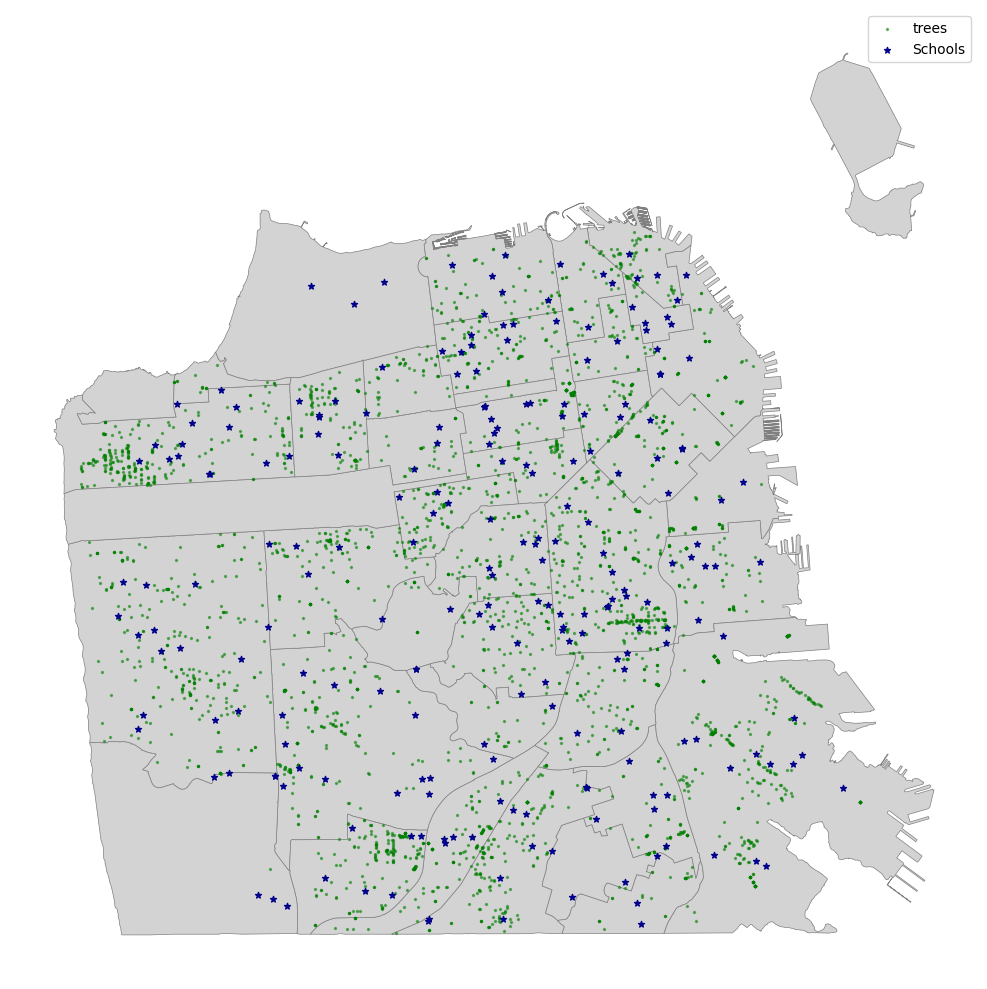

In [7]:
# Define our figure size and axes with `plt.subplots()`
fig, ax = plt.subplots(figsize=(10, 10))

# Plot our neighborhoods with `.plot()`
neighborhoods.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.5)

# Plot our trees with `.plot()`
trees.plot(ax=ax, color='green', markersize=2, alpha=0.5, label='trees')

# Plot our schools with `.plot()`
schools.plot(ax=ax, color='darkblue', markersize=20, marker='*', label='Schools')

# Optional parameters for legend; layout        
ax.legend()
ax.axis('off')
plt.tight_layout()

# Show our map with `plt.show()`!
plt.show()

## Question 1: Which neighborhoods have the most trees? 

### Merging neighborhoods data with trees data

Let's remind ourselves what our `neighborhoods` data looks like

In [8]:
neighborhoods.head()

,nhood,geometry
0,Western Addition,"POLYGON ((-122.42144 37.78557, -122.42136 37.7..."
1,West of Twin Peaks,"POLYGON ((-122.46104 37.75096, -122.46055 37.7..."
2,Visitacion Valley,"POLYGON ((-122.40385 37.71883, -122.40355 37.7..."
3,Twin Peaks,"POLYGON ((-122.44695 37.75655, -122.44595 37.7..."
4,South of Market,"POLYGON ((-122.40371 37.78404, -122.40271 37.7..."


And then join our neighborhoods data with our trees data using `gpd.sjoin()` with `within`

In [9]:
trees_with_nhood = gpd.sjoin(
    trees,
    neighborhoods,
    how='left',
    predicate='within'
)

In [10]:
trees_with_nhood.head(1) 
# index_right is the original index of the neighborhoods data

,TreeID,qLegalStatus,qSpecies,qAddress,SiteOrder,qSiteInfo,PlantType,qCaretaker,qCareAssistant,PlantDate,...,PlotSize,PermitNotes,XCoord,YCoord,Latitude,Longitude,Location,geometry,index_right,nhood
0,235418,DPW Maintained,Tree(s) ::,3466 21st St,2.0,Sidewalk: Curb side : Cutout,Tree,Private,NaN,2020 Jan 02 12:00:00 AM,...,Width 3ft,Permit Number 784779,6.005282e+06,2.103732e+06,37.756746,-122.424727,"(37.75674627772118, -122.42472718600857)",POINT (-122.42473 37.75675),22.0,Mission


In [11]:
len(trees_with_nhood[(trees_with_nhood['nhood'].isna()) & (trees_with_nhood['Location'].isna() == False)])

0

#### Getting recent trees by neighborhood

Use `groupby()` to see counts by neighborhood

In [12]:
# raw counts
trees_counts = trees_with_nhood.groupby(['nhood']).size().reset_index(name="count")
trees_counts.sort_values(by="count",ascending=False).head()
# size includes all values, count excludes missing ones

,nhood,count
0,Bayview Hunters Point,330
17,Mission,316
33,Sunset/Parkside,259
24,Outer Richmond,253
37,West of Twin Peaks,178


Make a new column for percentages if desired

In [13]:

total = trees_counts['count'].sum()
trees_counts['pct'] = (trees_counts['count'] / total * 100).round(1)

trees_counts.sort_values(by="pct",ascending=False).head()

,nhood,count,pct
0,Bayview Hunters Point,330,9.7
17,Mission,316,9.3
33,Sunset/Parkside,259,7.6
24,Outer Richmond,253,7.4
37,West of Twin Peaks,178,5.2


#### Let's map it!

Merge neighborhood geometries back in with `merge()`

In [14]:
neighborhood_trees = neighborhoods.merge(trees_counts, on='nhood', how='left')
neighborhood_trees.head()

,nhood,geometry,count,pct
0,Western Addition,"POLYGON ((-122.42144 37.78557, -122.42136 37.7...",89.0,2.6
1,West of Twin Peaks,"POLYGON ((-122.46104 37.75096, -122.46055 37.7...",178.0,5.2
2,Visitacion Valley,"POLYGON ((-122.40385 37.71883, -122.40355 37.7...",26.0,0.8
3,Twin Peaks,"POLYGON ((-122.44695 37.75655, -122.44595 37.7...",14.0,0.4
4,South of Market,"POLYGON ((-122.40371 37.78404, -122.40271 37.7...",102.0,3.0


Create a choropleth map with `plot()`

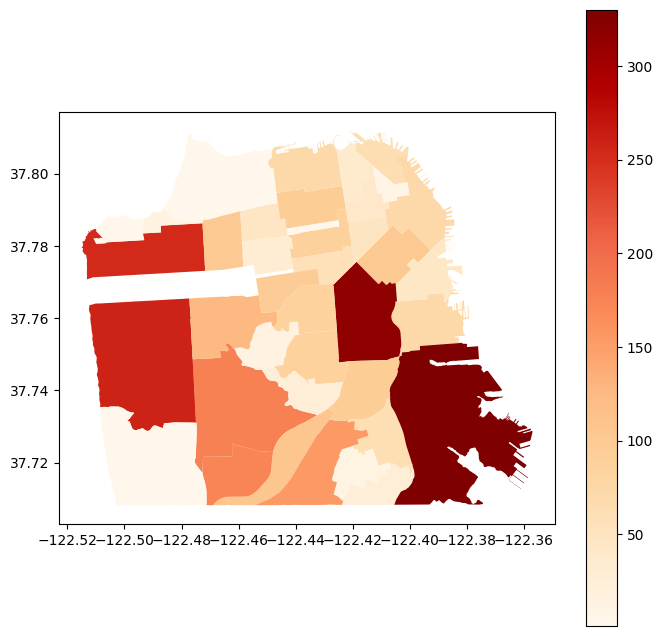

In [15]:
# set figure size
fig, ax = plt.subplots(figsize=(8, 8))

# set up map: specify column, color scheme, etc.
neighborhood_trees.plot(
    column="count", 
    cmap="OrRd", # color scheme - see more here https://matplotlib.org/stable/gallery/color/colormap_reference.html
    legend=True,
    linewidth=0.3,
    ax=ax
)

# show map
plt.show()

## Question 2: What's the most common type of tree being planted in each neighborhood? 

What are the most common types overall? Let's find out with `groupby()`

In [16]:
trees_with_nhood.groupby('qSpecies').size().reset_index(name="count").sort_values(by="count", ascending=False)

,qSpecies,count
101,Lophostemon confertus :: Brisbane Box,324
192,Tristaniopsis laurina :: Swamp Myrtle,233
111,Magnolia grandiflora :: Southern Magnolia,169
190,Tree(s) ::,138
149,Platanus x hispanica :: Sycamore: London Plane,130
...,...,...
19,Aesculus x carnea 'O'Neill' :: O'Neill Red Hor...,1
146,Platanus racemosa :: California Sycamore,1
42,Celtis sinensis :: Chinese Hackberry,1
90,Koelreuteria paniculata :: Golden Rain Tree,1


Let's break it down by neighborhood — first, `groupby()` neighborhood and request type

In [17]:
neighborhood_types = trees_with_nhood.groupby(['nhood','qSpecies']).size().reset_index(name="count")

Then sort and use `drop_duplicates()` to get the most common tree in each neighborhood

In [18]:
top_trees = neighborhood_types.sort_values(by="count", ascending=False).drop_duplicates(subset="nhood",keep="first")

Take a look at the data

In [19]:
top_trees

,nhood,qSpecies,count
1001,West of Twin Peaks,Tree(s) ::,56
441,Mission,Lophostemon confertus :: Brisbane Box,40
1014,Western Addition,Lophostemon confertus :: Brisbane Box,36
42,Bayview Hunters Point,Platanus x hispanica :: Sycamore: London Plane,34
711,Outer Richmond,Tristaniopsis laurina :: Swamp Myrtle,30
932,Sunset/Parkside,Tristaniopsis laurina :: Swamp Myrtle,27
192,Financial District/South Beach,Lophostemon confertus :: Brisbane Box,26
662,Outer Mission,Tristaniopsis laurina :: Swamp Myrtle,23
148,Excelsior,Eriobotrya deflexa :: Bronze Loquat,22
478,Mission Bay,Ginkgo biloba :: Maidenhair Tree,20


##### Let's map it!

Merge the data with the geometries with `.merge()`

In [20]:
neighborhood_top_trees = neighborhoods.merge(top_trees, on='nhood', how='left')


Visualize the data using `plot()`

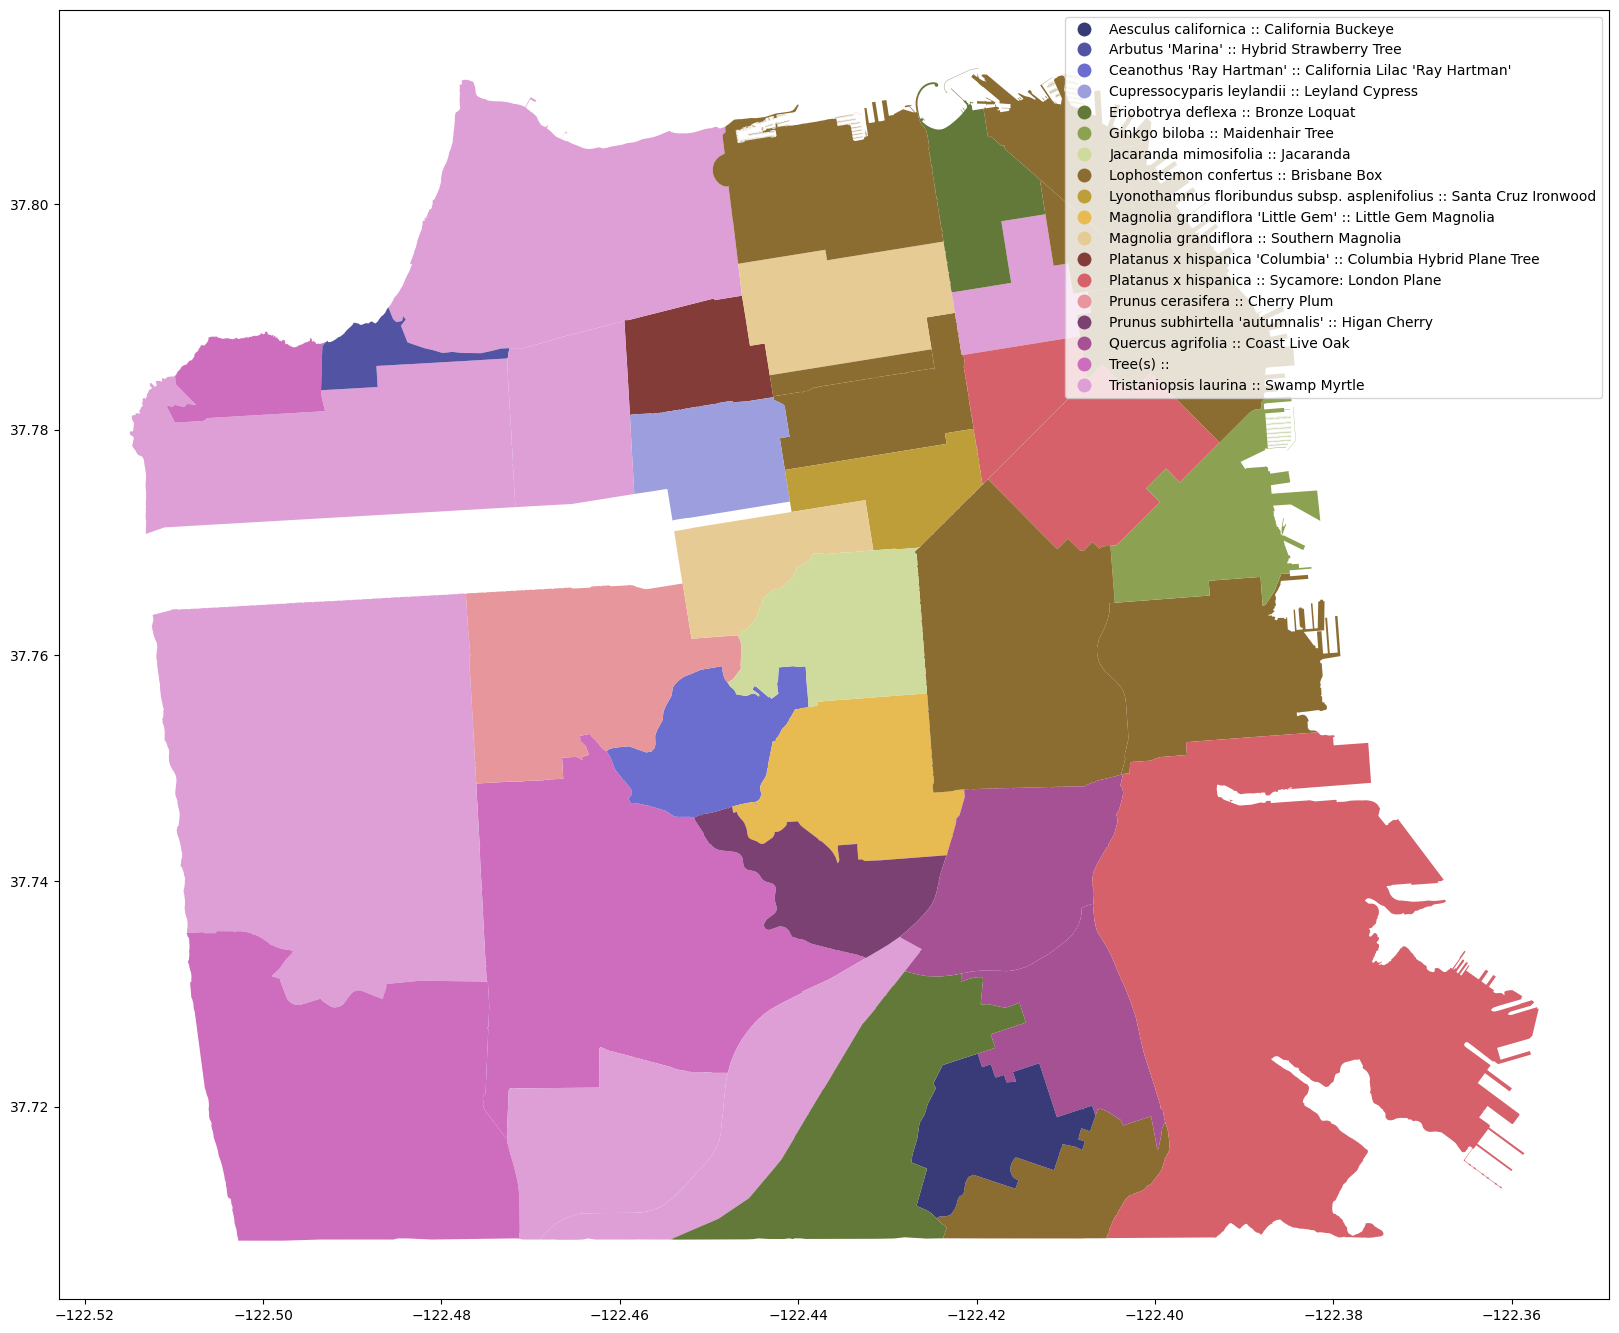

In [21]:
# set figure size
fig, ax = plt.subplots(figsize=(20, 20))

# set up map: specify column, color scheme, etc.
neighborhood_top_trees.plot(
    column="qSpecies", 
    cmap="tab20b", # color scheme - see more here https://matplotlib.org/stable/gallery/color/colormap_reference.html
    legend=True,
    linewidth=0.3,
    ax=ax
)

# show map
plt.show()

## Question 3: How many trees fall within 1,000 feet of a public school? 

##### Filter our schools to public schools using the `public_yesno` column

In [22]:
public_schools = schools[schools['public_yesno'] == "true"]

##### Switch our CRS to _geometry_ instead of _geography_. 
**Geographic** Coordinate Reference Systems use degrees (lat/long) to locate things on a sphere.
**Projected** Coordinate Reference Systems  use a 2D plane in meters and feet — helpful to measure distances!


We're going to use a local SF projection; adapt to your location as needed.

In [23]:
crs_feet = 'EPSG:7132'

Update the crs for schools and trees data

In [24]:
schools_proj = public_schools.to_crs(crs_feet)
trees_proj = trees.to_crs(crs_feet)

##### Create a buffer around the schools and find trees within it

Add a column with a buffer of 1000 ft around each school using `buffer()`

In [25]:
schools_proj['geometry'] = schools_proj.buffer(1000)

Create a new dataframe using `sjoin()` to find trees within the school buffer

In [26]:
within_buffers = gpd.sjoin(trees_proj, schools_proj[['school','geometry']], predicate='within')

Since one point might fall into more than one buffer area, let's drop duplicates (on `TreeID`).

In [27]:
within_buffers = within_buffers.drop_duplicates(subset=['TreeID'])

Check what share of trees is near a school

In [28]:
len(within_buffers) / len(trees_proj) * 100

32.9312762973352

##### Visualize the data

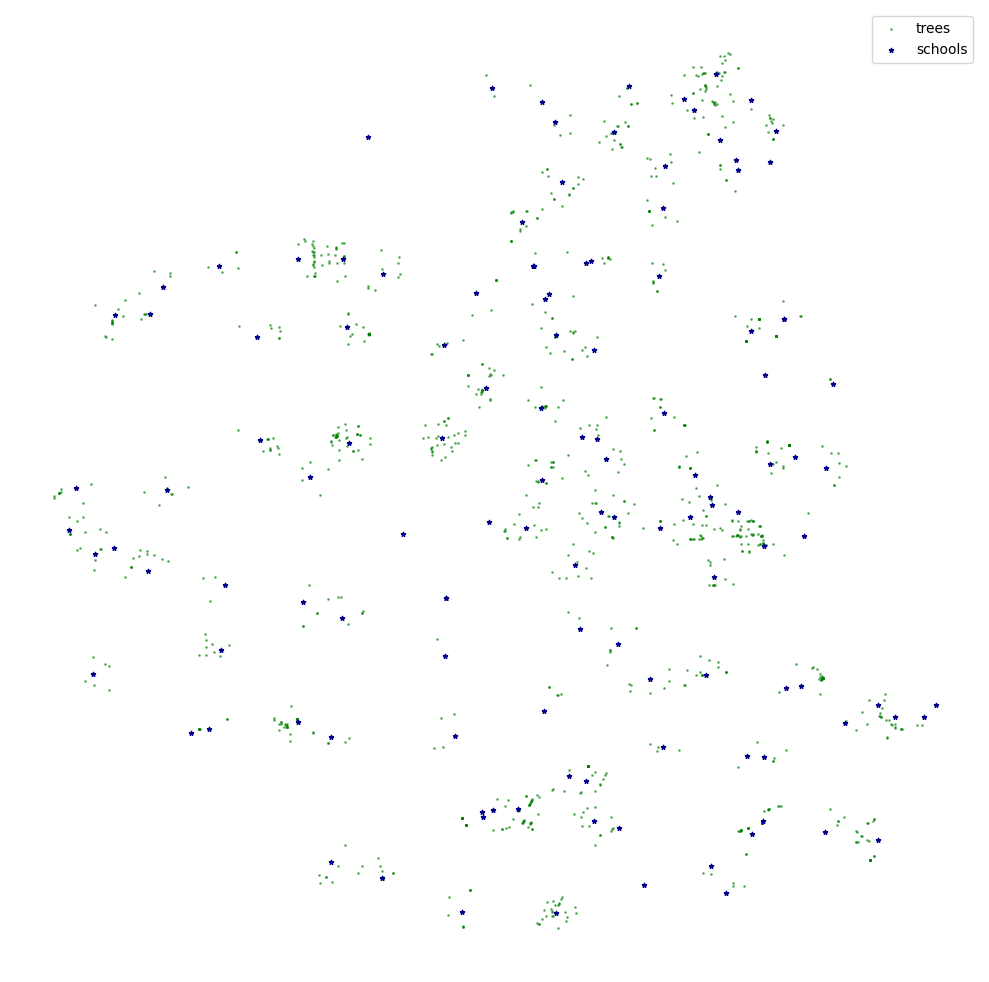

In [29]:
# Define our figure size and axes with `plt.subplots()`
fig, ax = plt.subplots(figsize=(10, 10))

# Plot our trees with `.plot()`
within_buffers.plot(ax=ax, color='green', markersize=1, alpha=0.5, label='trees')

# Plot our schools with `.plot()` - don't forget to change the CRS! 
public_schools.to_crs(crs_feet).plot(ax=ax, color='darkblue', markersize=10, marker="*", label='schools')

# Optional parameters for legend; layout        
ax.legend()
ax.axis('off')
plt.tight_layout()

# Show our map with `plt.show()`!
plt.show()

In [30]:
plt.savefig('map.svg')

<Figure size 640x480 with 0 Axes>

## Question 4: Which public school has the most trees nearby? 

Use `groupby` to count trees by school

In [31]:
near_school = within_buffers.groupby('school').size().sort_values(ascending=False).reset_index(name="count")

Sort and look at the data

In [32]:
near_school.sort_values(by='count',ascending=False)

,school,count
0,Independence High,38
1,Balboa High,36
2,Bryant Elementary,33
3,Grattan Elementary,31
4,Burton (Phillip and Sala) Academic High,31
...,...,...
105,King (Thomas Starr) Elementary,1
106,Sanchez Elementary,1
107,Marina Middle,1
108,Miraloma Elementary,1


At the end of the class, please shut down your terminal with `Ctrl + C`.